# EDA: Match Results + Elo Ratings

Exploring `data/results_with_elo.csv` (international match results merged with pre-match Elo ratings) before building a prediction model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/results_with_elo.csv", parse_dates=["date"])
df.shape

(49502, 11)

## Overview

In [2]:
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Rows: {len(df):,}")
print(f"Unique teams: {pd.concat([df['home_team'], df['away_team']]).nunique()}")
print(f"Tournaments: {df['tournament'].nunique()}")
df.dtypes

Date range: 1872-11-30 to 2026-07-09
Rows: 49,502
Unique teams: 336
Tournaments: 200


date          datetime64[ns]
home_team             object
away_team             object
home_score           float64
away_score           float64
tournament            object
city                  object
country               object
neutral                 bool
home_elo             float64
away_elo             float64
dtype: object

In [3]:
# Elo coverage by decade -- confirms where the merge_asof lookup has gaps
elo_missing = df["home_elo"].isna() | df["away_elo"].isna()
decade = (df["date"].dt.year // 10) * 10
coverage_by_decade = (1 - elo_missing.groupby(decade).mean()).rename("elo_coverage")
coverage_by_decade

date
1870    1.000000
1880    0.545455
1890    0.508475
1900    0.217391
1910    0.245455
1920    0.392298
1930    0.577386
1940    0.668667
1950    0.626287
1960    0.610905
1970    0.760948
1980    0.851542
1990    0.861031
2000    0.898488
2010    0.911720
2020    0.971275
Name: elo_coverage, dtype: float64

## Match outcomes & home advantage

In [4]:
def outcome(row):
    if pd.isna(row["home_score"]) or pd.isna(row["away_score"]):
        return np.nan  # unplayed/scheduled match, e.g. upcoming fixtures with no result yet
    if row["home_score"] > row["away_score"]:
        return "Home win"
    if row["home_score"] < row["away_score"]:
        return "Away win"
    return "Draw"

df["outcome"] = df.apply(outcome, axis=1)
print(f"Unplayed matches dropped from outcome analysis: {df['outcome'].isna().sum()}")
outcome_rates = df["outcome"].value_counts(normalize=True).reindex(["Home win", "Draw", "Away win"])
outcome_rates

Unplayed matches dropped from outcome analysis: 7


outcome
Home win    0.490070
Draw        0.227417
Away win    0.282513
Name: proportion, dtype: float64

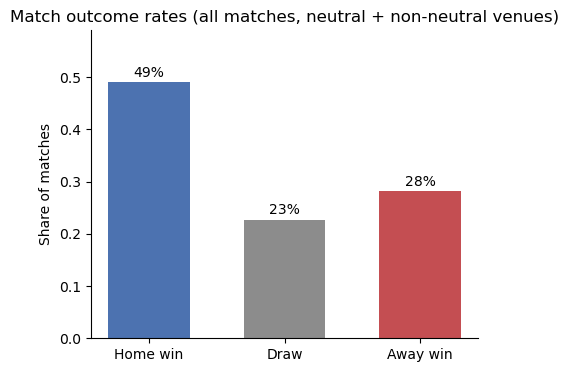

In [5]:
# Fixed categorical colors, one per outcome, used consistently in every chart below
OUTCOME_COLORS = {"Home win": "#4C72B0", "Draw": "#8C8C8C", "Away win": "#C44E52"}

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(
    outcome_rates.index,
    outcome_rates.values,
    color=[OUTCOME_COLORS[k] for k in outcome_rates.index],
    width=0.6,
)
for bar, val in zip(bars, outcome_rates.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01, f"{val:.0%}", ha="center", fontsize=10)
ax.set_ylabel("Share of matches")
ax.set_title("Match outcome rates (all matches, neutral + non-neutral venues)")
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, max(outcome_rates.values) + 0.1)
plt.show()

In [6]:
# Home advantage should vanish at neutral venues -- a useful sanity check on the data itself
neutral_rates = df.groupby("neutral")["outcome"].value_counts(normalize=True).unstack().reindex(
    columns=["Home win", "Draw", "Away win"]
)
neutral_rates.index = neutral_rates.index.map({False: "Non-neutral venue", True: "Neutral venue"})
neutral_rates

outcome,Home win,Draw,Away win
neutral,,,
Non-neutral venue,0.507481,0.228533,0.263986
Neutral venue,0.441882,0.224328,0.333790


## Goal distributions

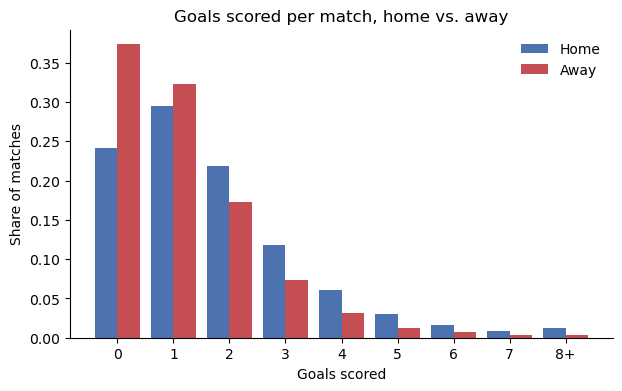

Mean home goals: 1.76
Mean away goals: 1.18


In [7]:
SIDE_COLORS = {"Home": "#4C72B0", "Away": "#C44E52"}

max_goals = 8
home_counts = df["home_score"].clip(upper=max_goals).value_counts(normalize=True).sort_index()
away_counts = df["away_score"].clip(upper=max_goals).value_counts(normalize=True).sort_index()
idx = range(max_goals + 1)
home_counts = home_counts.reindex(idx, fill_value=0)
away_counts = away_counts.reindex(idx, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 4))
width = 0.4
ax.bar([i - width / 2 for i in idx], home_counts.values, width=width, color=SIDE_COLORS["Home"], label="Home")
ax.bar([i + width / 2 for i in idx], away_counts.values, width=width, color=SIDE_COLORS["Away"], label="Away")
ax.set_xticks(list(idx))
ax.set_xticklabels([str(i) for i in range(max_goals)] + [f"{max_goals}+"])
ax.set_xlabel("Goals scored")
ax.set_ylabel("Share of matches")
ax.set_title("Goals scored per match, home vs. away")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.show()

print(f"Mean home goals: {df['home_score'].mean():.2f}")
print(f"Mean away goals: {df['away_score'].mean():.2f}")

## Elo rating distribution

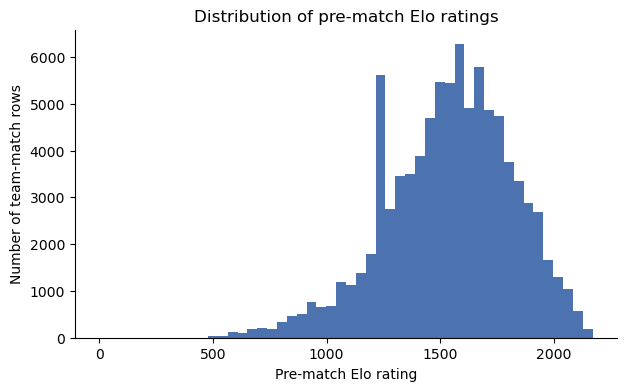

count    88558.000000
mean      1538.454403
std        279.375803
min          0.000000
25%       1353.000000
50%       1562.000000
75%       1737.000000
max       2171.000000
dtype: float64

In [8]:
all_elo = pd.concat([df["home_elo"], df["away_elo"]]).dropna()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(all_elo, bins=50, color="#4C72B0")
ax.set_xlabel("Pre-match Elo rating")
ax.set_ylabel("Number of team-match rows")
ax.set_title("Distribution of pre-match Elo ratings")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

all_elo.describe()

## Does Elo difference predict the outcome?

Restricting to matches with both teams' Elo available, bucket `home_elo - away_elo` and look at how outcome rates shift.

In [9]:
have_elo = df.dropna(subset=["home_elo", "away_elo"]).copy()
have_elo["elo_diff"] = have_elo["home_elo"] - have_elo["away_elo"]

bin_edges = [-np.inf, -400, -200, -100, 0, 100, 200, 400, np.inf]
bin_labels = ["< -400", "-400 to -200", "-200 to -100", "-100 to 0", "0 to 100", "100 to 200", "200 to 400", "> 400"]
have_elo["elo_diff_bin"] = pd.cut(have_elo["elo_diff"], bins=bin_edges, labels=bin_labels)

bucket_rates = (
    have_elo.groupby("elo_diff_bin", observed=True)["outcome"]
    .value_counts(normalize=True)
    .unstack()
    .reindex(columns=["Home win", "Draw", "Away win"])
    .reindex(bin_labels)
)
bucket_rates

outcome,Home win,Draw,Away win
elo_diff_bin,,,
< -400,0.091750,0.154202,0.754048
-400 to -200,0.220273,0.266951,0.512777
-200 to -100,0.333333,0.301901,0.364765
-100 to 0,0.425539,0.287557,0.286904
0 to 100,0.510695,0.272098,0.217207
100 to 200,0.608902,0.242430,0.148668
200 to 400,0.734256,0.179991,0.085753
> 400,0.878462,0.086347,0.035191


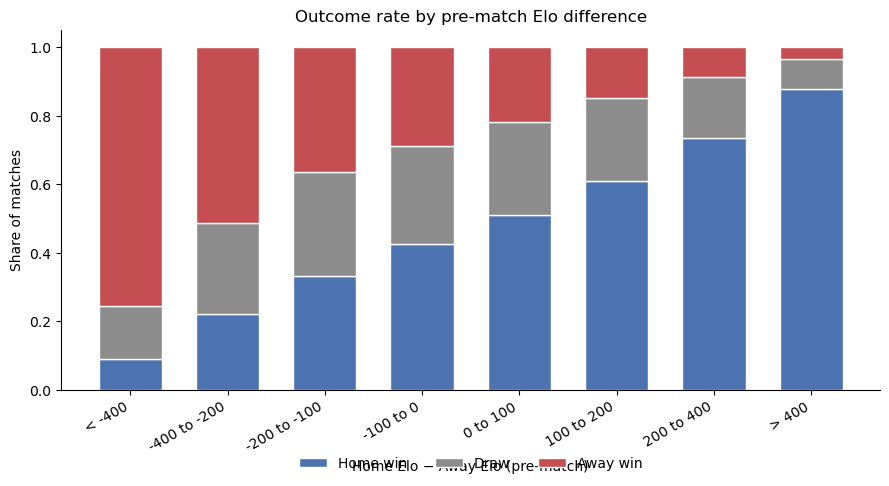

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(bucket_rates))
for col in ["Home win", "Draw", "Away win"]:
    ax.bar(
        bucket_rates.index,
        bucket_rates[col],
        bottom=bottom,
        color=OUTCOME_COLORS[col],
        label=col,
        width=0.65,
        edgecolor="white",
        linewidth=1,
    )
    bottom += bucket_rates[col].values

ax.set_ylabel("Share of matches")
ax.set_xlabel("Home Elo − Away Elo (pre-match)")
ax.set_title("Outcome rate by pre-match Elo difference")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Elo difference vs. goal difference

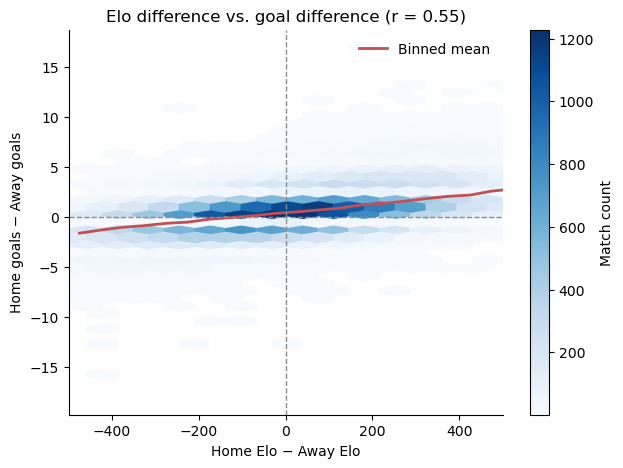

In [11]:
have_elo["goal_diff"] = have_elo["home_score"] - have_elo["away_score"]
corr = have_elo["elo_diff"].corr(have_elo["goal_diff"])

# Binned means to show the trend clearly through the point cloud
have_elo["elo_diff_bin50"] = (have_elo["elo_diff"] // 50) * 50
binned_mean = have_elo.groupby("elo_diff_bin50")["goal_diff"].mean()
binned_mean = binned_mean[(binned_mean.index >= -500) & (binned_mean.index <= 500)]

fig, ax = plt.subplots(figsize=(7, 5))
hb = ax.hexbin(have_elo["elo_diff"], have_elo["goal_diff"], gridsize=40, cmap="Blues", mincnt=1)
ax.plot(binned_mean.index + 25, binned_mean.values, color="#C44E52", linewidth=2, label="Binned mean")
ax.axhline(0, color="#8C8C8C", linewidth=1, linestyle="--")
ax.axvline(0, color="#8C8C8C", linewidth=1, linestyle="--")
ax.set_xlim(-500, 500)
ax.set_xlabel("Home Elo − Away Elo")
ax.set_ylabel("Home goals − Away goals")
ax.set_title(f"Elo difference vs. goal difference (r = {corr:.2f})")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
fig.colorbar(hb, ax=ax, label="Match count")
plt.show()

## Tournament breakdown & the World Cup subset

Since the target use case is World Cup prediction specifically, check how much World Cup data we actually have and whether it looks different from the full international dataset.

In [12]:
df["tournament"].value_counts().head(15)

tournament
Friendly                                18388
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1061
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
CFU Caribbean Cup qualification           606
Merdeka Tournament                        599
British Home Championship                 523
CONCACAF Nations League                   422
AFC Asian Cup                             421
Name: count, dtype: int64

In [13]:
wc = df[df["tournament"] == "FIFA World Cup"]
wc_elo = wc.dropna(subset=["home_elo", "away_elo"])

print(f"World Cup matches: {len(wc)}")
print(f"World Cup matches with Elo coverage: {len(wc_elo)} ({len(wc_elo) / len(wc):.0%})")
print()
print("World Cup outcome rates:")
print(wc["outcome"].value_counts(normalize=True).reindex(["Home win", "Draw", "Away win"]))
print()
print("All-matches outcome rates (for comparison):")
print(outcome_rates)

World Cup matches: 1061
World Cup matches with Elo coverage: 973 (92%)

World Cup outcome rates:
outcome
Home win    0.458254
Draw        0.224858
Away win    0.316888
Name: proportion, dtype: float64

All-matches outcome rates (for comparison):
outcome
Home win    0.490070
Draw        0.227417
Away win    0.282513
Name: proportion, dtype: float64


## Takeaways

- Elo difference clearly separates outcomes: the home team's win rate rises steadily as `home_elo - away_elo` increases, and the Elo/goal-difference correlation confirms Elo carries real signal.
- Home advantage is real at non-neutral venues and disappears at neutral ones, as expected -- a useful sanity check that the data is clean.
- World Cup matches are a small, more evenly-matched slice of the full dataset (bigger disparities get filtered out by qualification), so a model trained on all internationals may need care when evaluated specifically on World Cup games.
- Elo coverage is ~92%+ for matches since 2000, so gaps shouldn't meaningfully hurt a model trained on recent data.